# Estimate leakage severity as a function of radius

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import leakagelib

>>> PyXSPEC is not installed, you will no be able to use it.


This code plots the leakage severity as a function of radius. To start, we'll create a model point source and get the sky calibrated PSF. We'll assume Moments data, and use the PSF at position angle zero.

In [2]:
DETECTOR = 3
SOURCE_SIZE = 101 # Pixels
PIXEL_SIZE = 1 # arcsec. Since we aren't using data, it's OK to make it this small

source = leakagelib.Source.delta(SOURCE_SIZE, PIXEL_SIZE)
psf = leakagelib.PSF.sky_cal(DETECTOR, source, 0)
combo = leakagelib.PSFSourceCombo(source, psf, use_nn=False)

The next step is to get the normalized leakage patterns. We'll use a sample power-law spectrum.

In [5]:
spectrum = leakagelib.DataSpectrum.from_power_law_index(2)
pred_i, q_norm, u_norm = combo.compute_leakage(spectrum, normalize=True)

>>> Using cached xEffectiveArea object at /opt/homebrew/anaconda3/lib/python3.12/site-packages/ixpeobssim/caldb/ixpe/gpd/cpf/arf/ixpe_d1_obssim20240101_v013.arf...


These leakage images are the raw Q and U patterns of the events. If we started to extract physical polarizations, we would divide by mu. So let's do that.

In [9]:
pd_image = np.sqrt(q_norm**2 + u_norm**2) *  spectrum.get_avg_one_over_mu(use_nn=False)

Let's view that image

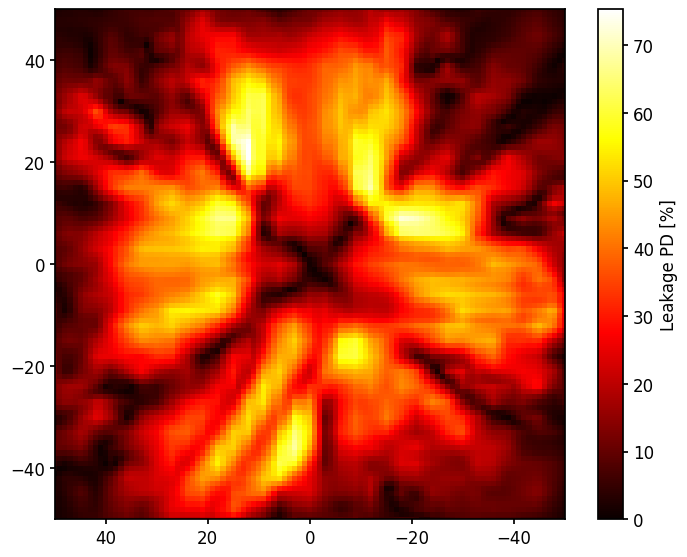

In [12]:
fig, ax = plt.subplots()
c = ax.pcolormesh(source.pixel_centers, source.pixel_centers, np.transpose(pd_image)*100, vmin=0)
ax.set_xlim(50,-50)
ax.set_ylim(-50, 50)
ax.set_aspect("equal")
fig.colorbar(c, label="Leakage PD [%]");

Now we plot the PD as a function of radius. 

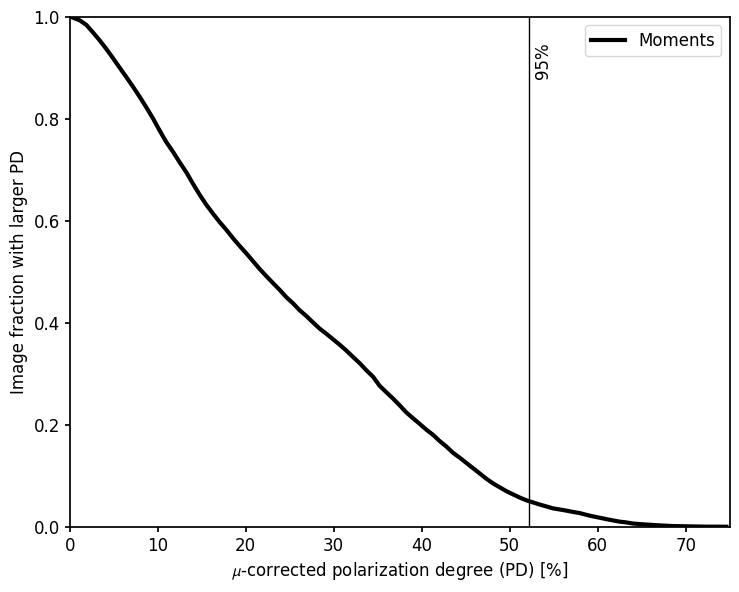

In [33]:
fig, ax = plt.subplots()    
pd_bins = np.linspace(0, 0.75, 100)
pd_bin_centers = (pd_bins[1:] + pd_bins[:-1]) / 2
pd_counts = np.histogram(pd_image, pd_bins)[0]
pd_cdf = 1 - np.cumsum(pd_counts) / np.sum(pd_counts)

ax.plot(100*pd_bin_centers, pd_cdf, lw=3, color='k', label="Moments")
limit = np.interp(0.05, np.flip(pd_cdf), np.flip(pd_bin_centers))
ax.axvline(100*limit, lw=1, color='k')
ax.text(100*limit+0.5, 0.95, f"95%", ha='left', va='top', rotation=90)

ax.set_ylim(0, 1)
ax.set_xlim(0, 75)
ax.set_xlabel("$\\mu$-corrected polarization degree (PD) [%]")
ax.set_ylabel("Image fraction with larger PD")
ax.legend();

You can try going back and changing detectors or the analysis methods. For example: neural nets give much less leakage.

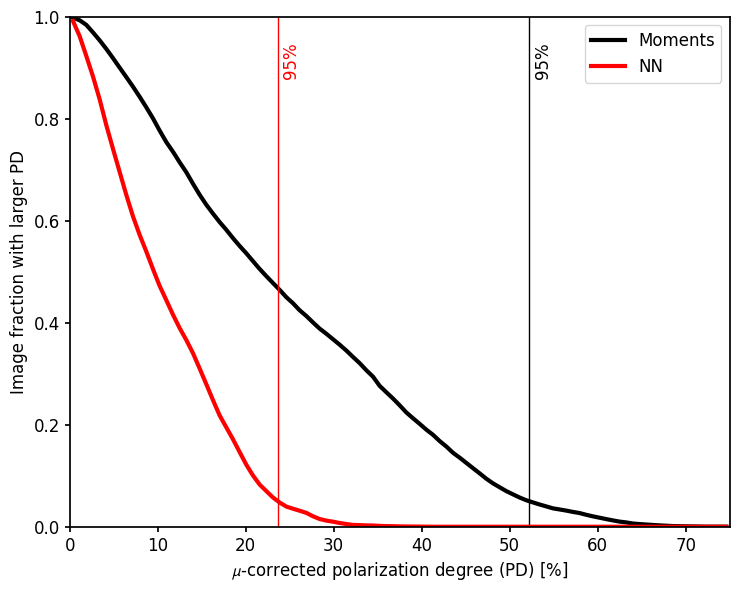

In [34]:
combo = leakagelib.PSFSourceCombo(source, psf, use_nn=True)
pred_i, q_norm, u_norm = combo.compute_leakage(spectrum, normalize=True)
pd_image_nn = np.sqrt(q_norm**2 + u_norm**2) *  spectrum.get_avg_one_over_mu(use_nn=True)

fig, ax = plt.subplots()    
pd_counts = np.histogram(pd_image_nn, pd_bins)[0]
pd_cdf_nn = 1 - np.cumsum(pd_counts) / np.sum(pd_counts)

ax.plot(100*pd_bin_centers, pd_cdf, lw=3, color='k', label="Moments")
limit = np.interp(0.05, np.flip(pd_cdf), np.flip(pd_bin_centers))
ax.axvline(100*limit, lw=1, color='k')
ax.text(100*limit+0.5, 0.95, f"95%", ha='left', va='top', rotation=90)

ax.plot(100*pd_bin_centers, pd_cdf_nn, lw=3, color='r', label="NN")
limit = np.interp(0.05, np.flip(pd_cdf_nn), np.flip(pd_bin_centers))
ax.axvline(100*limit, lw=1, color='r')
ax.text(100*limit+0.5, 0.95, f"95%", ha='left', va='top', rotation=90, color='r')

ax.set_ylim(0, 1)
ax.set_xlim(0, 75)
ax.set_xlabel("$\\mu$-corrected polarization degree (PD) [%]")
ax.set_ylabel("Image fraction with larger PD")
ax.legend();